# CS 182/282A Fall 2026 — HW02: Optimization and Initialization

Run this supplied notebook from top to bottom and use its plots and measurements for the Q3 discussion in your written PDF. The optimizer, initialization, gradient-logging, and training implementations are complete; the default experiments require no code changes.

Keep the supplied seeds and settings for the initial comparison. RMSProp is an optional additional experiment: set `RUN_OPTIONAL_RMSPROP = True` in the imports cell to include it. You may explore other settings after recording the supplied run, using validation data to make comparisons.

Colab setup uses Drive for persistent experiment files. Local setup is described in `README.md`. Generated histories are saved in `experiment_logs/` for your own inspection.


In [1]:
# Recover a stale Drive working directory before imports or subprocesses.
import os
if os.path.isdir('/content'):
    os.chdir('/content')
import errno
import importlib.util
from pathlib import Path

IN_COLAB = importlib.util.find_spec('google.colab') is not None if importlib.util.find_spec('google') else False
if IN_COLAB:
    from google.colab import drive
    force_remount = False
    try:
        Path('/content/drive/MyDrive').stat()
    except FileNotFoundError:
        pass
    except OSError as error:
        if error.errno in (errno.ENOTCONN, errno.EIO, getattr(errno, 'ESTALE', 116)):
            force_remount = True
            print('Drive is disconnected; reconnecting the mount.')
        else:
            raise
    drive.mount('/content/drive', force_remount=force_remount)
    try:
        Path('/content/drive/MyDrive').stat()
    except OSError as error:
        raise RuntimeError('Drive is still unavailable. Restart the Colab session, rerun this cell, and complete Drive authorization.') from error
else:
    print('Local environment: using the supplied experiment directory.')


Local environment: using the supplied experiment directory.


In [2]:
# Persistent Colab workspace; no shell escaping or symlink is needed.
if IN_COLAB:
    workspace = Path('/content/drive/MyDrive/cs182hw2_fa26')
    workspace.mkdir(parents=True, exist_ok=True)


In [3]:
# Use working installed packages first; install only missing dependencies.
import importlib
import importlib.util
import subprocess
import sys

dependencies = {'numpy': 'numpy>=1.26,<3', 'matplotlib': 'matplotlib>=3.8,<4', 'imageio': 'imageio>=2.34,<3'}
missing = [requirement for module, requirement in dependencies.items() if importlib.util.find_spec(module) is None]
if missing:
    command = [sys.executable, '-m', 'pip', 'install', '--disable-pip-version-check', '--no-input',
               '--progress-bar', 'off', '--timeout', '20', '--retries', '1', *missing]
    print('Installing missing packages (maximum 180 seconds):', missing, flush=True)
    try:
        subprocess.run(command, check=True, timeout=180)
    except (subprocess.TimeoutExpired, subprocess.CalledProcessError, OSError) as error:
        raise RuntimeError('Dependency installation did not finish. Check the connection, restart the session, and rerun setup. '
                           'For a local environment, install requirements.txt in your active Python environment. '
                           'The failed command was: ' + ' '.join(command)) from error
    importlib.invalidate_caches()
for module in dependencies:
    try:
        imported = importlib.import_module(module)
    except Exception as error:
        raise RuntimeError(f'The installed {module} package could not import. Restart the session; if this persists, use a fresh runtime/environment and rerun setup.') from error
    print(module, getattr(imported, '__version__', 'available'))

%matplotlib inline
# After optional edits to helper .py files, restart the session and rerun from the top.
print('Setup complete.')


numpy 1.26.4


matplotlib 3.11.2
imageio 2.38.1


Setup complete.


In [4]:
# Use the supplied Fall 2026 experiment package; preserve older workspaces.
if IN_COLAB:
    import subprocess
    import sys
    repo = workspace / 'cs182fa26_public'
    def has_experiment_package(directory):
        helper = directory / 'hw02/code/assignment_utils.py'
        return helper.is_file() and "EXPERIMENT_PACKAGE_VERSION = 'fa26-q3-experiments-v1'" in helper.read_text(encoding='utf-8')
    if repo.exists() and not has_experiment_package(repo):
        repo = workspace / 'cs182fa26_public_q3_experiments_v1'
        print('Using a separate checkout for the supplied experiments; older files are preserved.')
    if not repo.exists():
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/Berkeley-CS182/cs182fa26_public.git', str(repo)], check=True, timeout=180)
    if not has_experiment_package(repo):
        raise RuntimeError('This checkout predates the supplied Q3 experiments. Preserve your files, choose a fresh checkout directory, and rerun setup.')
    os.chdir(repo / 'hw02/code')
# Solution notebook: when opened from hw02/codesolution, use the supplied code next to it.
if not Path('deeplearning/classifiers/fc_net.py').is_file() and Path('../code/deeplearning/classifiers/fc_net.py').is_file():
    os.chdir('../code')
if not Path('deeplearning/classifiers/fc_net.py').is_file():
    raise FileNotFoundError('Open this notebook from its supplied code directory, next to deeplearning/.')
import sys
import importlib
code_directory = Path.cwd().resolve()
# Refresh only this assignment's module names after switching package paths.
for name in list(sys.modules):
    if name == 'assignment_utils' or name == 'deeplearning' or name.startswith('deeplearning.'):
        module_file = getattr(sys.modules[name], '__file__', None)
        if module_file and code_directory not in Path(module_file).resolve().parents:
            del sys.modules[name]
sys.path.insert(0, str(code_directory))
importlib.invalidate_caches()
print('Experiment directory:', code_directory)


Experiment directory: code


In [5]:
# Download CIFAR-10 once; verify the archive before extracting it.
from assignment_utils import download_cifar10
download_cifar10()


(about 170 MB; 60-second connection/read timeout)...


Downloaded 10 MiB...


Downloaded 20 MiB...


Downloaded 30 MiB...


Downloaded 40 MiB...


...

Downloaded 130 MiB...


Downloaded 140 MiB...


Downloaded 150 MiB...


Downloaded 160 MiB...


PosixPath('deeplearning/datasets/cifar-10-batches-py')

# Optimization Methods and Initialization

Until now, you've always used Gradient Descent to update the parameters and minimize the cost. In this notebook, you will learn more advanced optimization methods that can speed up learning and perhaps even get you to a better final value for the cost function. Having a good optimization algorithm can be the difference between waiting days vs. just a few hours to get a good result. 

Gradient descent goes "downhill" on a cost function $J$. Think of it as trying to do this: 
<img src="https://raw.githubusercontent.com/amanchadha/coursera-deep-learning-specialization/master/C2%20-%20Improving%20Deep%20Neural%20Networks%20Hyperparameter%20tuning%2C%20Regularization%20and%20Optimization/Week%202/images/cost.jpg">
<caption><center> <u> <strong>Figure 1</strong> </u>: <strong>Minimizing the cost is like finding the lowest point in a hilly landscape<strong/><br> At each step of the training, you update your parameters following a certain direction to try to get to the lowest possible point. </center></caption>


In [6]:
# As usual, a bit of setup

import json
import time
import numpy as np
import matplotlib.pyplot as plt
from deeplearning.classifiers.fc_net import *
from deeplearning.data_utils import get_CIFAR10_data
from deeplearning.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from deeplearning.solver import Solver
import random 
seed = 7
random.seed(seed)
np.random.seed(seed)

plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))
# Set True to include the supplied optional RMSProp experiment.
RUN_OPTIONAL_RMSPROP = False
Path('experiment_logs').mkdir(exist_ok=True)


In [7]:
# Load the (preprocessed) CIFAR10 data.

data = get_CIFAR10_data()
for k, v in data.items():
    print('%s: ' % k, v.shape)


deeplearning/datasets/cifar-10-batches-py/data_batch_1
deeplearning/datasets/cifar-10-batches-py/data_batch_2


deeplearning/datasets/cifar-10-batches-py/data_batch_3
deeplearning/datasets/cifar-10-batches-py/data_batch_4
deeplearning/datasets/cifar-10-batches-py/data_batch_5


deeplearning/datasets/cifar-10-batches-py/test_batch


X_train:  (49000, 3, 32, 32)
y_train:  (49000,)
X_val:  (1000, 3, 32, 32)
y_val:  (1000,)
X_test:  (1000, 3, 32, 32)
y_test:  (1000,)


## 1 - Stochastic Gradient Descent

A simple optimization method in machine learning is gradient descent (GD). When you take gradient steps with respect to all $m$ examples on each step, it is also called Batch Gradient Descent. 

A variant of this is Stochastic Gradient Descent (SGD), which is equivalent to mini-batch gradient descent where each mini-batch has just 1 example. The supplied update rule does not change. What changes is that you would be computing gradients on just one training example at a time, rather than on the whole training set. The code examples below illustrate the difference between stochastic gradient descent and (batch) gradient descent. 

In Stochastic Gradient Descent, you use only 1 training example before updating the parameters. When the training set is large, SGD can be faster. But the parameters will "oscillate" toward the minimum rather than converge smoothly. Here is an illustration of this: 

<img src="https://raw.githubusercontent.com/amanchadha/coursera-deep-learning-specialization/master/C2%20-%20Improving%20Deep%20Neural%20Networks%20Hyperparameter%20tuning%2C%20Regularization%20and%20Optimization/Week%202/images/kiank_sgd.png">
<caption><center> <u>  <strong>Figure 1</strong> </u> : <strong>SGD vs GD</strong><br> "+" denotes a minimum of the cost. SGD leads to many oscillations to reach convergence. But each step is a lot faster to compute for SGD than for GD, as it uses only one training example (vs. the whole batch for GD). </center></caption>

In the following code snippet, we will use SGD to optimze a five-layer FullyConnectedNet so that it overfits to 50 training exmaples. 
In this notebook, `sgd` names the unmodified gradient update rule; `Solver` uses minibatches larger than one.


(Iteration 1 / 40) loss: 94.233583
(Epoch 0 / 20) train acc: 0.140000; val_acc: 0.123000
(Epoch 1 / 20) train acc: 0.120000; val_acc: 0.102000
(Epoch 2 / 20) train acc: 0.320000; val_acc: 0.118000
(Epoch 3 / 20) train acc: 0.480000; val_acc: 0.133000
(Epoch 4 / 20) train acc: 0.720000; val_acc: 0.112000
(Epoch 5 / 20) train acc: 0.800000; val_acc: 0.105000
(Iteration 11 / 40) loss: 1.410664
(Epoch 6 / 20) train acc: 0.940000; val_acc: 0.108000
(Epoch 7 / 20) train acc: 1.000000; val_acc: 0.116000


(Epoch 8 / 20) train acc: 0.980000; val_acc: 0.113000


(Epoch 9 / 20) train acc: 1.000000; val_acc: 0.116000
(Epoch 10 / 20) train acc: 1.000000; val_acc: 0.116000
(Iteration 21 / 40) loss: 0.000076
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.116000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.116000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.116000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.116000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.116000
(Iteration 31 / 40) loss: 0.000327
(Epoch 16 / 20) train acc: 1.000000; val_acc: 0.115000
(Epoch 17 / 20) train acc: 1.000000; val_acc: 0.115000


(Epoch 18 / 20) train acc: 1.000000; val_acc: 0.115000


(Epoch 19 / 20) train acc: 1.000000; val_acc: 0.115000
(Epoch 20 / 20) train acc: 1.000000; val_acc: 0.115000


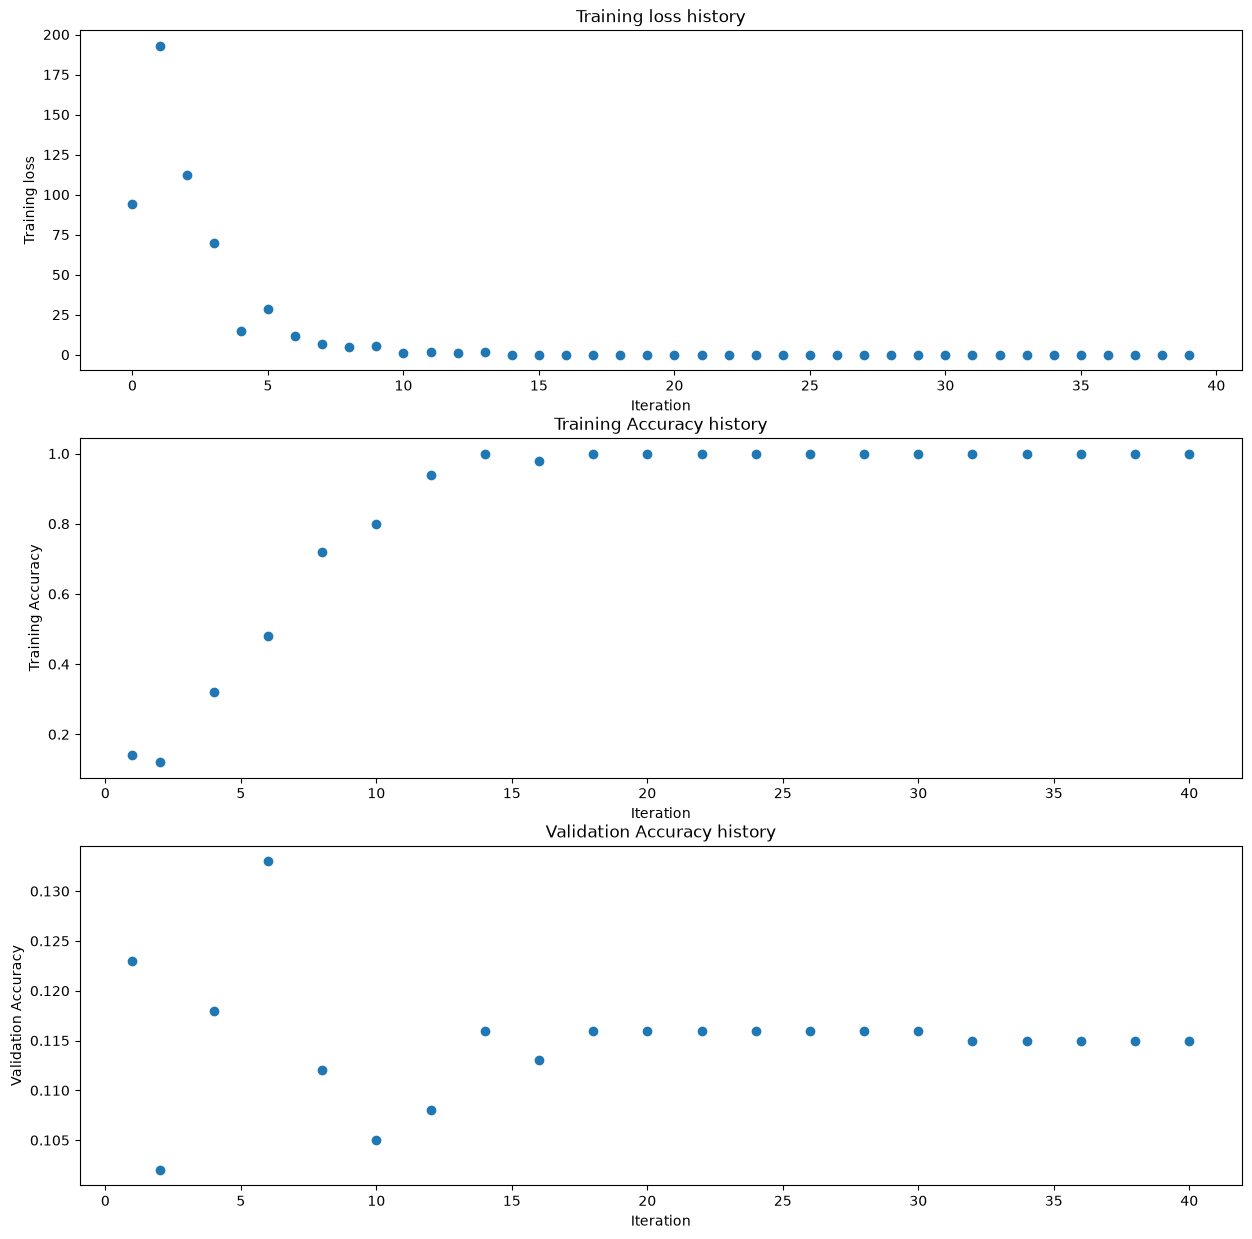

In [8]:
## Use a five-layer Net to overfit 50 training examples.
 

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

weight_scale = 1e-1
learning_rate = 1e-3
model = FullyConnectedNet([100, 100, 100, 100],
                weight_scale=weight_scale, dtype=np.float64)

solver = Solver(model, small_data,
                print_every=10, num_epochs=20, batch_size=25,
                update_rule='sgd', log_acc_iteration=True,
                optim_config={
                  'learning_rate': learning_rate,
                }
         )
solver.train()

plt.subplot(3, 1, 1)
plt.plot(solver.loss_history, 'o')
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')

plt.subplot(3, 1, 2)
plt.plot(solver.log_acc_iteration_history, solver.train_acc_history, 'o')
plt.title('Training Accuracy history')
plt.xlabel('Iteration')
plt.ylabel('Training Accuracy')

plt.subplot(3, 1, 3)
plt.plot(solver.log_acc_iteration_history, solver.val_acc_history, 'o')
plt.title('Validation Accuracy history')
plt.xlabel('Iteration')
plt.ylabel('Validation Accuracy')
plt.gcf().set_size_inches(15, 15)

plt.show()


## 2 - Momentum

Because mini-batch gradient descent makes a parameter update after seeing just a subset of examples, the direction of the update has some variance, and so the path taken by mini-batch gradient descent will "oscillate" toward convergence. Using momentum can reduce these oscillations. 

Momentum takes into account the past gradients to smooth out the update. We will store the 'direction' of the previous gradients in the variable $v$. Here it is an exponentially weighted sum: this convention omits the factor 1-momentum, which can be absorbed into the learning rate. You can also think of $v$ as the "velocity" of a ball rolling downhill, building up speed (and momentum) according to the direction of the gradient/slope of the hill. 

<img src="https://raw.githubusercontent.com/amanchadha/coursera-deep-learning-specialization/master/C2%20-%20Improving%20Deep%20Neural%20Networks%20Hyperparameter%20tuning%2C%20Regularization%20and%20Optimization/Week%202/images/opt_momentum.png">
<caption><center> <u><strong>Figure 3</strong></u>: The red arrows shows the direction taken by one step of mini-batch gradient descent with momentum. The blue points show the direction of the gradient (with respect to the current mini-batch) on each step. Rather than just following the gradient, we let the gradient influence v (velocity) and then take a step in the direction of v.<br> </center>

 The momentum update rule for a weight matrix w is: 

$$ \begin{cases}
v_{dw}^t = m * v_{dw}^{(t-1)} + dw\\
{w} = w - \alpha  v_{dw}^t
\end{cases}\tag{3}$$


where $m$ is the momentum and $\alpha$ is the learning rate. Note that the iterator `t` starts at 1. 

Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochstic gradient descent, its temporal smoothing differs from increasing the minibatch size. 

The supplied `sgd_momentum` function in `deeplearning/optim.py` implements this update. Run the numerical check below; the relative errors should be below 1e-7.


In [9]:
from deeplearning.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-3, 'velocity': v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
 [-0.39994, -0.347375263, -0.294810526, -0.242245789, -0.189681053], 
 [-0.137116316, -0.084551579, -0.031986842, 0.020577895, 0.073142632], 
 [0.125707368, 0.178272105, 0.230836842, 0.283401579, 0.335966316], 
 [0.388531053, 0.441095789, 0.493660526, 0.546225263, 0.59879]])
expected_velocity = np.asarray([
 [-0.06, 0.006842105, 0.073684211, 0.140526316, 0.207368421], 
 [0.274210526, 0.341052632, 0.407894737, 0.474736842, 0.541578947], 
 [0.608421053, 0.675263158, 0.742105263, 0.808947368, 0.875789474], 
 [0.942631579, 1.009473684, 1.076315789, 1.143157895, 1.21]
])

print ('next_w error: ', rel_error(next_w, expected_next_w))
print ('velocity error: ', rel_error(expected_velocity, config['velocity']))


next_w error:  6.3941900171621575e-09
velocity error:  1.923077600561035e-08


Run the following to compare a six-layer network trained with SGD and SGD with momentum. The two runs begin at the same parameters and use the same random seed. Describe the observed loss and accuracy curves; an optimizer ranking is specific to these settings.

**Solution.** In this run both optimizers start from the same parameters (loss about 2.6, 11% training accuracy). SGD with momentum lowers the training loss faster and ends the 5 epochs at 50.3% training accuracy, against 44.6% for plain SGD. Validation accuracy is about the same for both (33.7% and 33.6%).

Momentum accumulates the gradient directions that agree from one minibatch to the next and partly cancels the directions that flip sign. Along consistent directions it therefore takes larger effective steps, while it damps the oscillations from minibatch noise. With this learning rate and budget that speeds up training; the ranking is specific to these settings.

running with  sgd
(Iteration 1 / 200) loss: 2.644035
(Epoch 0 / 5) train acc: 0.111000; val_acc: 0.114000
(Iteration 11 / 200) loss: 2.190758
(Iteration 21 / 200) loss: 2.026035
(Iteration 31 / 200) loss: 2.127682


(Epoch 1 / 5) train acc: 0.284000; val_acc: 0.243000
(Iteration 41 / 200) loss: 2.113272


(Iteration 51 / 200) loss: 1.941638
(Iteration 61 / 200) loss: 1.979350
(Iteration 71 / 200) loss: 1.955930
(Epoch 2 / 5) train acc: 0.331000; val_acc: 0.284000
(Iteration 81 / 200) loss: 1.808481
(Iteration 91 / 200) loss: 1.871617


(Iteration 101 / 200) loss: 1.690442


(Iteration 111 / 200) loss: 1.731147
(Epoch 3 / 5) train acc: 0.402000; val_acc: 0.313000
(Iteration 121 / 200) loss: 1.724367
(Iteration 131 / 200) loss: 1.699723
(Iteration 141 / 200) loss: 1.568954
(Iteration 151 / 200) loss: 1.772790


(Epoch 4 / 5) train acc: 0.423000; val_acc: 0.318000
(Iteration 161 / 200) loss: 1.803135
(Iteration 171 / 200) loss: 1.684806
(Iteration 181 / 200) loss: 1.603086
(Iteration 191 / 200) loss: 1.535284
(Epoch 5 / 5) train acc: 0.446000; val_acc: 0.336000

running with  sgd_momentum
(Iteration 1 / 200) loss: 2.644035
(Epoch 0 / 5) train acc: 0.111000; val_acc: 0.114000


(Iteration 11 / 200) loss: 2.095360
(Iteration 21 / 200) loss: 1.806401
(Iteration 31 / 200) loss: 2.012146
(Epoch 1 / 5) train acc: 0.315000; val_acc: 0.281000
(Iteration 41 / 200) loss: 2.017092
(Iteration 51 / 200) loss: 1.774738
(Iteration 61 / 200) loss: 1.688893


(Iteration 71 / 200) loss: 1.772179
(Epoch 2 / 5) train acc: 0.397000; val_acc: 0.316000
(Iteration 81 / 200) loss: 1.582188
(Iteration 91 / 200) loss: 1.686387
(Iteration 101 / 200) loss: 1.531687
(Iteration 111 / 200) loss: 1.609059


(Epoch 3 / 5) train acc: 0.403000; val_acc: 0.328000
(Iteration 121 / 200) loss: 1.455550
(Iteration 131 / 200) loss: 1.659947
(Iteration 141 / 200) loss: 1.574338
(Iteration 151 / 200) loss: 1.479002
(Epoch 4 / 5) train acc: 0.503000; val_acc: 0.350000
(Iteration 161 / 200) loss: 1.487964
(Iteration 171 / 200) loss: 1.413304


(Iteration 181 / 200) loss: 1.291319
(Iteration 191 / 200) loss: 1.270954
(Epoch 5 / 5) train acc: 0.503000; val_acc: 0.337000



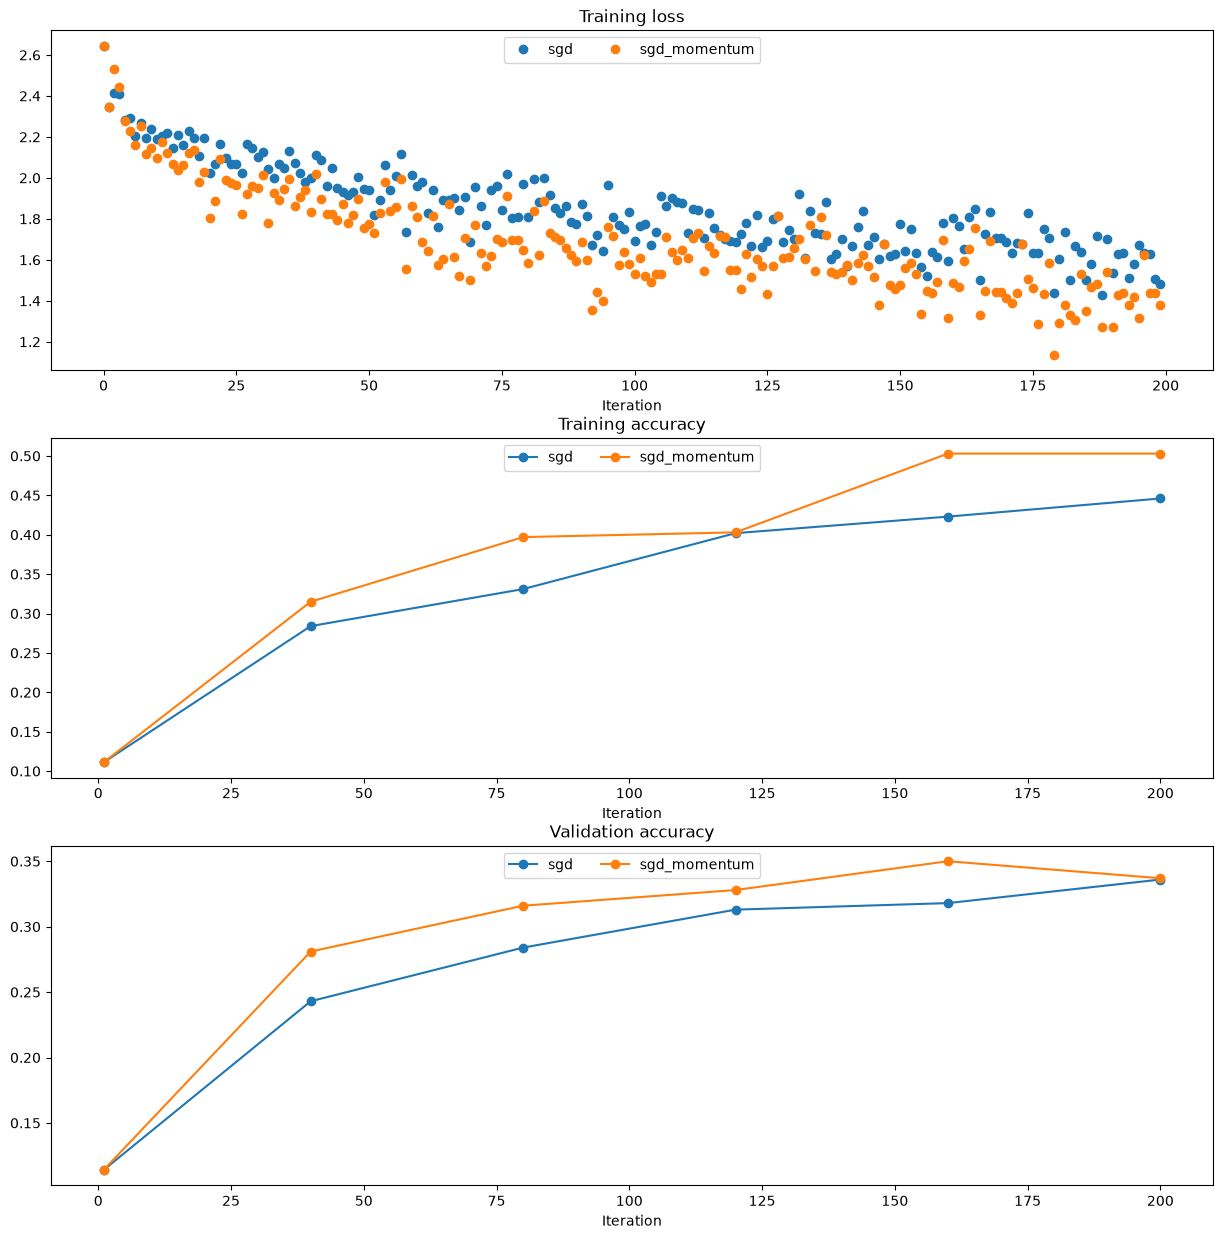

In [10]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print ('running with ', update_rule)
    np.random.seed(7)
    model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)

    solver = Solver(model, small_data,
                  num_epochs=5, batch_size=100,
                  update_rule=update_rule,
                  optim_config={
                    'learning_rate': 1e-2,
                  },
                  verbose=True, log_acc_iteration=True)
    solvers[update_rule] = solver
    solver.train()
    os.makedirs("experiment_logs", exist_ok=True)
    solver.record_histories_as_npz("experiment_logs/optimizer_experiment_{}".format(update_rule))
    print()

plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Iteration')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Iteration')

for update_rule, solver in solvers.items():
    plt.subplot(3, 1, 1)
    plt.plot(solver.loss_history, 'o', label=update_rule)

    plt.subplot(3, 1, 2)
    plt.plot(solver.log_acc_iteration_history, solver.train_acc_history, '-o', label=update_rule)

    plt.subplot(3, 1, 3)
    plt.plot(solver.log_acc_iteration_history, solver.val_acc_history, '-o', label=update_rule)

for i in [1, 2, 3]:
    plt.subplot(3, 1, i)
    plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()


Both momentum and larger batches can reduce gradient variability, but they are not equivalent algorithms. Compare plain SGD at batch size 400 with momentum at batch size 100 using the supplied three seeds.

The two methods use the same number of optimizer steps. Inspect the mean final training accuracies and their absolute difference, then discuss the comparison in your written PDF. A larger batch processes more examples when the number of steps is fixed. The observed difference depends on this dataset and these settings; it is not a universal equivalence between larger batches and momentum.


**Solution.** Mean final training accuracy over seeds 100, 200 and 300 in this run: plain SGD at batch size 400 reached 47.8%, SGD with momentum at batch size 100 reached 49.0%, a difference of 1.2 percentage points after the same number of optimizer steps.

Both methods reduce the variability of the update and end up close, but they are not the same algorithm. A batch of 400 averages four times as many *fresh* gradients at the current parameters, so it lowers the variance of each step at four times the cost per step. Momentum averages gradients from *earlier* iterates for free, and with this convention ($v = m\,v + dw$) it also scales the step along consistent directions by up to $1/(1-m) = 10$. So momentum changes the effective step size as well as the noise, while the larger batch only changes the noise.

running with sgd
seed = 100
(Iteration 1 / 300) loss: 2.612065
(Epoch 0 / 20) train acc: 0.104000; val_acc: 0.093000
(Iteration 11 / 300) loss: 2.226197
(Epoch 1 / 20) train acc: 0.204000; val_acc: 0.192000


(Iteration 21 / 300) loss: 2.114793
(Epoch 2 / 20) train acc: 0.229000; val_acc: 0.250000
(Iteration 31 / 300) loss: 2.037384
(Iteration 41 / 300) loss: 1.955199


(Epoch 3 / 20) train acc: 0.266000; val_acc: 0.286000
(Iteration 51 / 300) loss: 1.981767
(Epoch 4 / 20) train acc: 0.303000; val_acc: 0.306000
(Iteration 61 / 300) loss: 1.942956
(Iteration 71 / 300) loss: 1.908990


(Epoch 5 / 20) train acc: 0.281000; val_acc: 0.297000
(Iteration 81 / 300) loss: 1.847013
(Epoch 6 / 20) train acc: 0.337000; val_acc: 0.309000
(Iteration 91 / 300) loss: 1.829625
(Iteration 101 / 300) loss: 1.837606


(Epoch 7 / 20) train acc: 0.329000; val_acc: 0.306000
(Iteration 111 / 300) loss: 1.802956
(Epoch 8 / 20) train acc: 0.367000; val_acc: 0.322000
(Iteration 121 / 300) loss: 1.862365
(Iteration 131 / 300) loss: 1.838962


...

(Epoch 1 / 5) train acc: 0.338000; val_acc: 0.307000
(Iteration 61 / 300) loss: 1.773888
(Iteration 71 / 300) loss: 1.678792
(Iteration 81 / 300) loss: 1.893509
(Iteration 91 / 300) loss: 1.844371
(Iteration 101 / 300) loss: 1.652441
(Iteration 111 / 300) loss: 1.581435


(Epoch 2 / 5) train acc: 0.408000; val_acc: 0.354000
(Iteration 121 / 300) loss: 1.680423
(Iteration 131 / 300) loss: 1.691756
(Iteration 141 / 300) loss: 1.631880
(Iteration 151 / 300) loss: 1.735215
(Iteration 161 / 300) loss: 1.791722
(Iteration 171 / 300) loss: 1.736622


(Epoch 3 / 5) train acc: 0.451000; val_acc: 0.352000
(Iteration 181 / 300) loss: 1.396440
(Iteration 191 / 300) loss: 1.561125
(Iteration 201 / 300) loss: 1.347849
(Iteration 211 / 300) loss: 1.326418
(Iteration 221 / 300) loss: 1.425347
(Iteration 231 / 300) loss: 1.632146


(Epoch 4 / 5) train acc: 0.466000; val_acc: 0.341000
(Iteration 241 / 300) loss: 1.438809
(Iteration 251 / 300) loss: 1.577824
(Iteration 261 / 300) loss: 1.644744
(Iteration 271 / 300) loss: 1.627075
(Iteration 281 / 300) loss: 1.567045
(Iteration 291 / 300) loss: 1.455764


(Epoch 5 / 5) train acc: 0.506000; val_acc: 0.366000
Average Training Acc for sgd: 0.47800000000000004
Average Training Acc for sgd_momentum: 0.49
Train Acc Difference:  0.011999999999999955


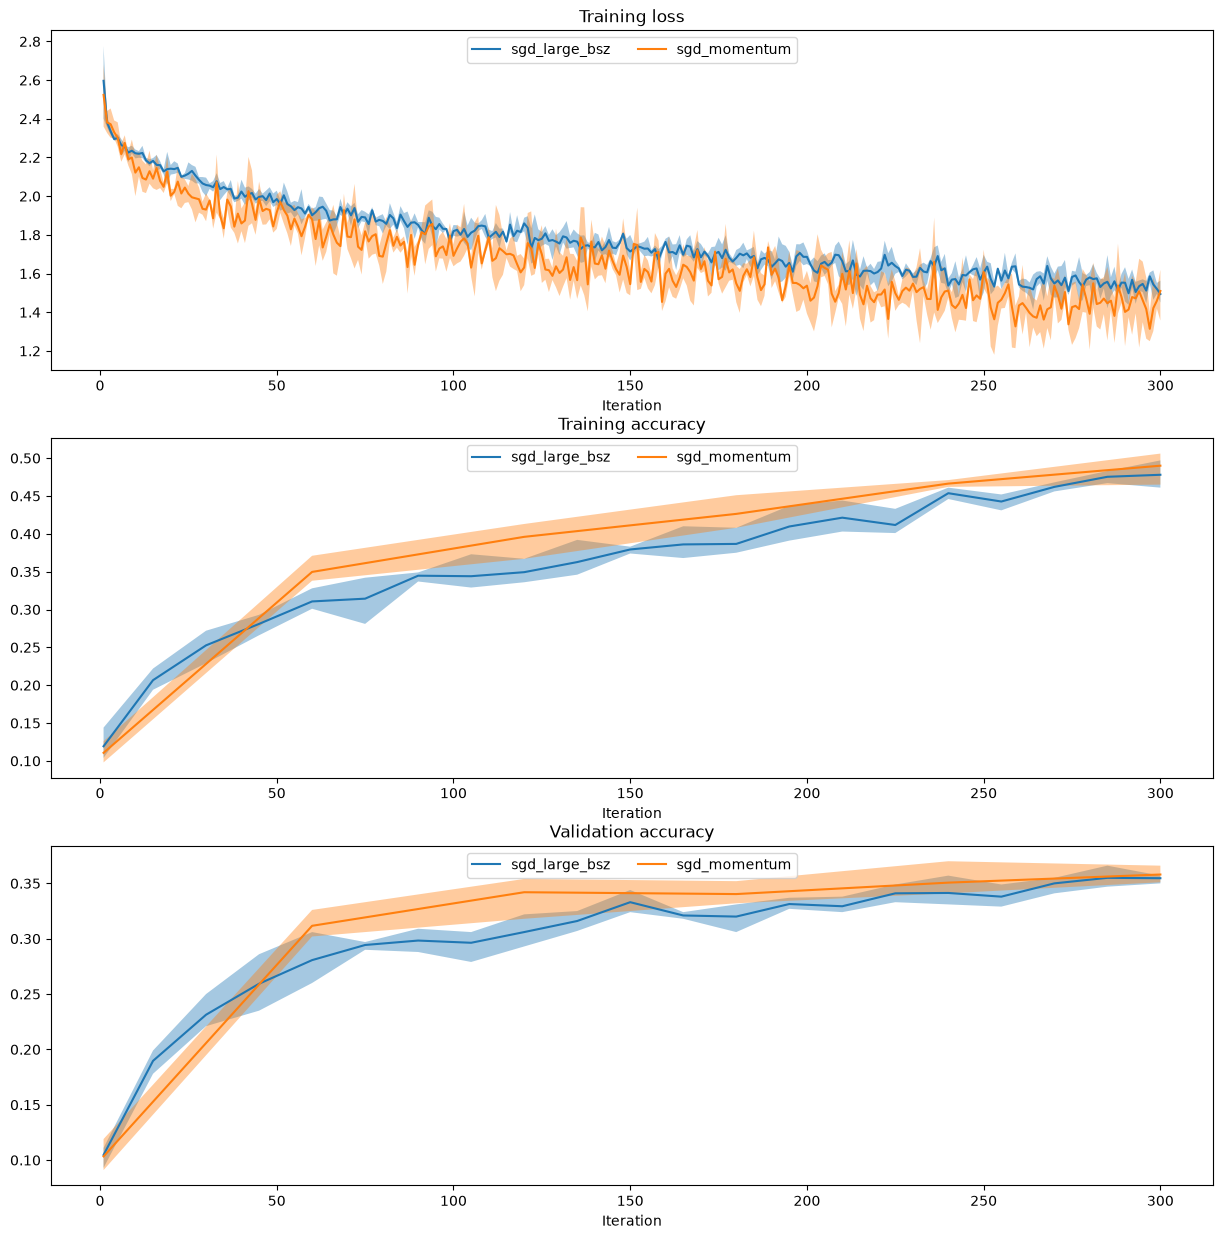

In [11]:
batch_sizes = {
  'sgd_momentum': 100,
  'sgd': 400,  # supplied larger-batch comparison
}

assert batch_sizes['sgd'] > 0 and batch_sizes['sgd'] % 100 == 0
assert 6000 % batch_sizes['sgd'] == 0, 'Choose an SGD batch size that divides 6000.'
num_train = 6000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}
total_acc = {}

labels = {
  'sgd_momentum': 'sgd_momentum',
  'sgd': 'sgd_large_bsz',
}

for update_rule in ['sgd', 'sgd_momentum']:
    print('running with', update_rule)
    # set the epochs so that we have the same number of steps for both rules
    training_epochs = 5 * int(batch_sizes[update_rule]/100)
    solvers[update_rule] = {}
    total_acc[update_rule] = 0

    for seed in [100, 200, 300]:
        np.random.seed(seed)
        print('seed =', seed)
        model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)

        solver = Solver(
            model, small_data,
            num_epochs=training_epochs,
            batch_size=batch_sizes[update_rule],
            update_rule=update_rule,
            optim_config={
                'learning_rate': 1e-2,  # please do not change the learning rate
            },
            verbose=True,
            log_acc_iteration=True)
        
        solvers[update_rule][seed] = solver
        solver.train()
        solver.record_histories_as_npz(
            "experiment_logs/sgd_momentum_compare_{}_{}"
            .format(update_rule, seed)
        )

        total_acc[update_rule] += solvers[update_rule][seed].train_acc_history[-1]

print('Average Training Acc for sgd:', total_acc['sgd'] / 3)
print('Average Training Acc for sgd_momentum:', total_acc['sgd_momentum'] / 3)
print('Train Acc Difference: ',
       abs(total_acc['sgd'] / 3 - total_acc['sgd_momentum'] / 3))

def plot_solver_seeds(solver_s, x_field, y_field, seeds, label):
    a = np.array([getattr(solver_s[seed], y_field) for seed in seeds])
    if x_field is None:
        plt_x = np.arange(a.shape[1]) + 1
    else:
        plt_x = getattr(solver_s[seeds[0]], x_field)
    plt.plot(plt_x, a.mean(axis=0), label=label)
    plt.fill_between(plt_x, a.min(axis=0), a.max(axis=0), alpha=0.4)

plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Iteration')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Iteration')

for update_rule, solver_s in solvers.items():
    plt.subplot(3, 1, 1)
    # plt.plot(solver.loss_history, 'o', label=labels[update_rule])
    plot_solver_seeds(solver_s, None, 'loss_history',
                      [100, 200, 300], labels[update_rule])

    plt.subplot(3, 1, 2)
    # plt.plot(solver.log_acc_iteration_history, solver.train_acc_history, '-o', label=labels[update_rule])
    plot_solver_seeds(solver_s, 'log_acc_iteration_history', 'train_acc_history',
                      [100, 200, 300], labels[update_rule])

    plt.subplot(3, 1, 3)
    # plt.plot(solver.log_acc_iteration_history, solver.val_acc_history, '-o', label=labels[update_rule])
    plot_solver_seeds(solver_s, 'log_acc_iteration_history', 'val_acc_history',
                      [100, 200, 300], labels[update_rule])

for i in [1, 2, 3]:
    plt.subplot(3, 1, i)
    plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()


## 3 - RMSProp (Optional)
As we saw with the "Implicit Regularization" example in lecture, using one fixed learning rate will cause the optimizer to converge more slowly in some parameters than in others. This may not be ideal since we need to set the learning rate small so that parameters that change quickly don't diverge, but parameters that change more slowly may need larger learning rates to converge quickly. RMSProp is an **adaptive** algorithm, which adapts the learning rate of each parameter individually in order to help all parameters converge at similar speed to each other. 

RMSProp works by keeping an exponentially weighted moving average of the squared partial derivatives of the loss with respect each parameter, which serves as an estimate to how quickly that parameter is changing. RMSProp divides each gradient component by the square root of this moving average plus epsilon. This adapts update scales; it does not make all gradient components equal.

The RMSPRop update rule is as follows:

$$\begin{cases}
r = \rho r + (1 - \rho) (\frac{\partial \mathcal{J} }{\partial W })^2 \\
w = w - \alpha \frac{1}{\sqrt{r} + \varepsilon} \frac{\partial \mathcal{J} }{\partial W }
\end{cases}$$
where:
- $\rho$ is the "decay rate" that controls the exponentially weighted average. 
- $\alpha$ is the learning rate.
- $\varepsilon$ is a very small number to avoid dividing by zero.

The supplied `rmsprop` function in `deeplearning/optim.py` implements this update. The optional numerical check below verifies the update.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

Set `RUN_OPTIONAL_RMSPROP = True` in the imports cell to enable its numerical check and comparison. Otherwise both are skipped.


In [12]:
if RUN_OPTIONAL_RMSPROP:
    # Test RMSProp implementation; you should see errors less than 1e-7.
    from deeplearning.optim import rmsprop
    
    N, D = 4, 5
    w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
    dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
    cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
    
    config = {'learning_rate': 1e-2, 'cache': cache}
    next_w, _ = rmsprop(w, dw, config=config)
    
    expected_next_w = np.asarray([
      [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
      [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
      [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
      [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
    expected_cache = np.asarray([
      [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
      [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
      [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
      [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])
    
    print ('next_w error: ', rel_error(expected_next_w, next_w))
    print ('cache error: ', rel_error(expected_cache, config['cache']))
else:
    print('Skipping optional RMSProp.')


Skipping optional RMSProp.


## 4 - Adam
Adam is one of the most effective optimization algorithms for training neural networks. It combines ideas from RMSProp and Momentum. 

<strong>How does Adam work?</strong>
1. It calculates an exponentially weighted average of past gradients, and stores it in variables $m$ (before bias correction) and $m^{corrected}$ (with bias correction). 
2. It calculates an exponentially weighted average of the squares of the past gradients, and  stores it in variables $v$ (before bias correction) and $v^{corrected}$ (with bias correction). 
3. It updates parameters in a direction based on combining information from both $m^{corrected}$ and $v^{corrected}$.

$$\begin{cases}
m_{dw} = \beta_1 m_{dw} + (1 - \beta_1) \frac{\partial \mathcal{J} }{ \partial W } \\
m^{corrected}_{dw} = \frac{m_{dw}}{1 - (\beta_1)^t} \\
v_{dw} = \beta_2 v_{dw} + (1 - \beta_2) (\frac{\partial \mathcal{J} }{\partial W })^2 \\
v^{corrected}_{dw} = \frac{v_{dw}}{1 - (\beta_2)^t} \\
w = w - \alpha \frac{m^{corrected}_{dw}}{\sqrt{v^{corrected}_{dw}} + \varepsilon}
\end{cases}$$
where:
- t counts the number of steps taken of Adam 
- $\beta_1$ and $\beta_2$ are hyperparameters that control the two exponentially weighted averages
- $\alpha$ is the learning rate
- $\varepsilon$ is a very small number to avoid dividing by zero


The supplied `adam` function in `deeplearning/optim.py` implements this update. Run the numerical check below.

[1] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [13]:
# Test Adam implementation; you should see errors around 1e-7 or less.
from deeplearning.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])
expected_t = 6

print ('next_w error: ', rel_error(expected_next_w, next_w))
print ('v error: ', rel_error(expected_v, config['v']))
print ('m error: ', rel_error(expected_m, config['m']))
print ('t error: ', rel_error(expected_t, config['t']))


next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09
t error:  0.0


Compare SGD, momentum, and Adam using the supplied settings. Enable the optional RMSProp toggle to include it. Inspect their loss and accuracy curves and discuss the differences in your written PDF.


**Solution.** After 5 epochs in this run: SGD reached 45.0% training / 33.2% validation accuracy, SGD with momentum 51.2% / 36.3%, and Adam 57.8% / 37.4%. Adam lowers the training loss fastest and momentum is second.

Adam combines momentum with a per-parameter step size: dividing by the running RMS of each parameter's gradient makes parameters with small gradients move about as fast as parameters with large gradients, which helps in a deep network whose layers see very different gradient scales. Adam's larger gap between training and validation accuracy shows it is also starting to fit the 4,000 training examples more closely. These rankings depend on the supplied learning rates and short budget.

running with  sgd
(Iteration 1 / 200) loss: 2.920601
(Epoch 0 / 5) train acc: 0.114000; val_acc: 0.106000
(Iteration 11 / 200) loss: 2.194586
(Iteration 21 / 200) loss: 2.168989
(Iteration 31 / 200) loss: 1.993583


(Epoch 1 / 5) train acc: 0.290000; val_acc: 0.266000
(Iteration 41 / 200) loss: 2.066329


(Iteration 51 / 200) loss: 1.879198
(Iteration 61 / 200) loss: 1.931991
(Iteration 71 / 200) loss: 1.942465
(Epoch 2 / 5) train acc: 0.316000; val_acc: 0.293000
(Iteration 81 / 200) loss: 1.866048
(Iteration 91 / 200) loss: 1.759450


(Iteration 101 / 200) loss: 1.714417


(Iteration 111 / 200) loss: 1.814777
(Epoch 3 / 5) train acc: 0.362000; val_acc: 0.322000
(Iteration 121 / 200) loss: 1.748681
(Iteration 131 / 200) loss: 1.681962
(Iteration 141 / 200) loss: 1.878652
(Iteration 151 / 200) loss: 1.814017


...

(Iteration 181 / 200) loss: 1.744552
(Iteration 191 / 200) loss: 1.602645
(Epoch 5 / 5) train acc: 0.512000; val_acc: 0.363000

running with  adam
(Iteration 1 / 200) loss: 2.920601
(Epoch 0 / 5) train acc: 0.135000; val_acc: 0.137000
(Iteration 11 / 200) loss: 2.105130


(Iteration 21 / 200) loss: 2.071603
(Iteration 31 / 200) loss: 1.773153
(Epoch 1 / 5) train acc: 0.370000; val_acc: 0.340000
(Iteration 41 / 200) loss: 1.817409
(Iteration 51 / 200) loss: 1.687912
(Iteration 61 / 200) loss: 1.602724


(Iteration 71 / 200) loss: 1.774896
(Epoch 2 / 5) train acc: 0.431000; val_acc: 0.349000
(Iteration 81 / 200) loss: 1.564152
(Iteration 91 / 200) loss: 1.449915
(Iteration 101 / 200) loss: 1.675994
(Iteration 111 / 200) loss: 1.423475


(Epoch 3 / 5) train acc: 0.492000; val_acc: 0.344000
(Iteration 121 / 200) loss: 1.514898
(Iteration 131 / 200) loss: 1.306070
(Iteration 141 / 200) loss: 1.573788
(Iteration 151 / 200) loss: 1.465149
(Epoch 4 / 5) train acc: 0.532000; val_acc: 0.337000
(Iteration 161 / 200) loss: 1.265995


(Iteration 171 / 200) loss: 1.359124
(Iteration 181 / 200) loss: 1.360041
(Iteration 191 / 200) loss: 1.390574
(Epoch 5 / 5) train acc: 0.578000; val_acc: 0.374000



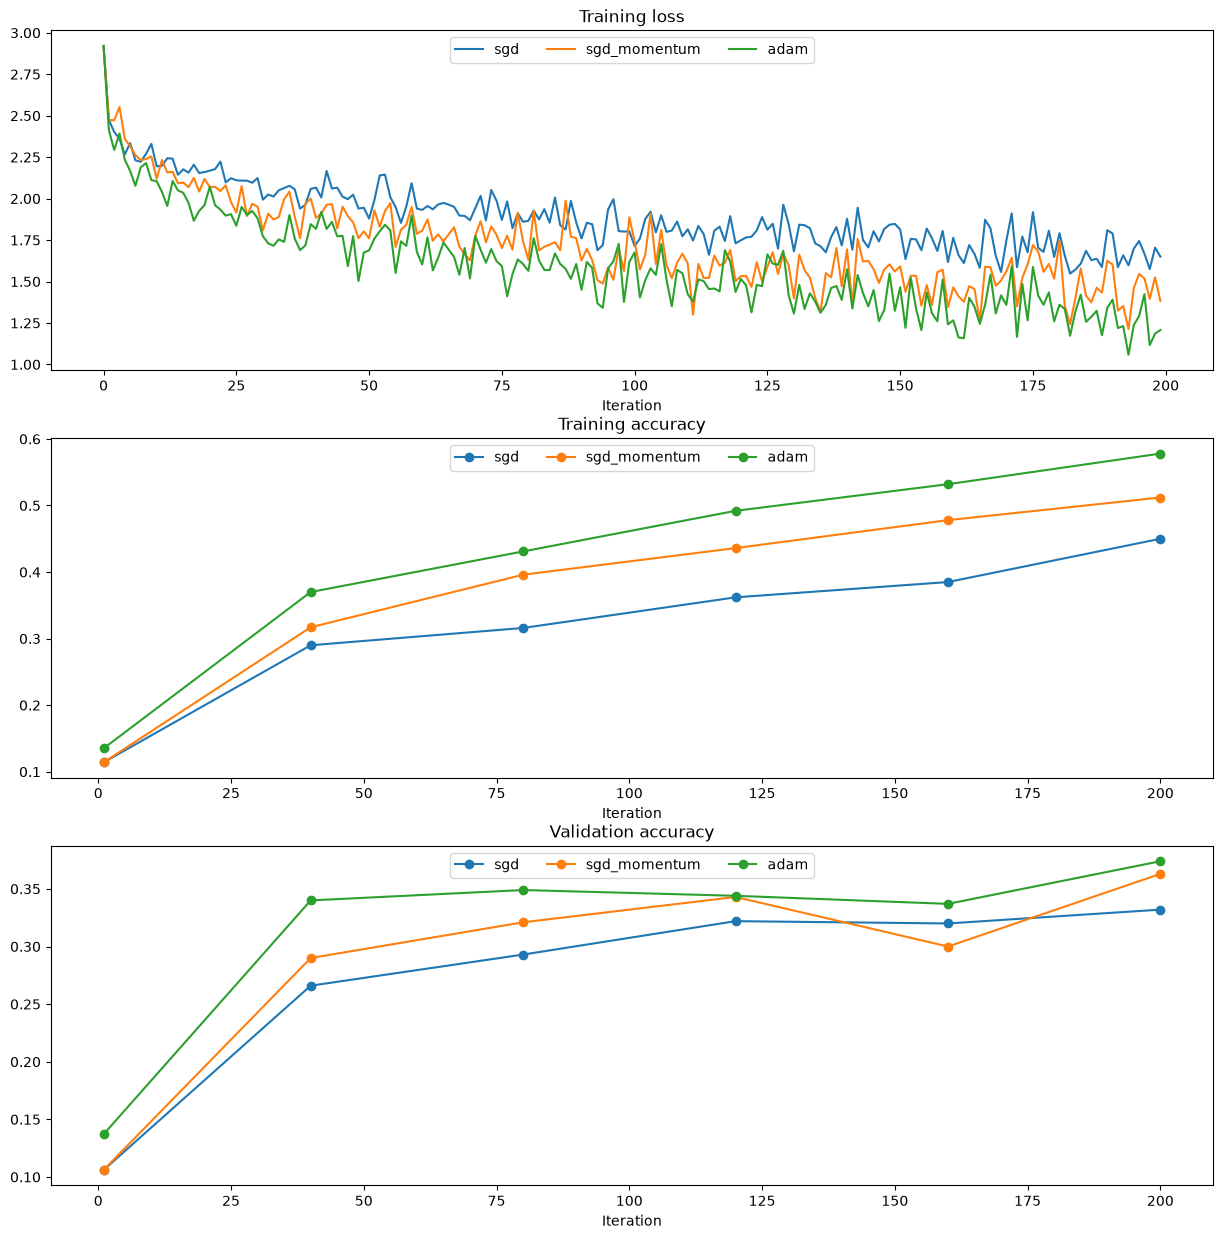

In [14]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3, 'sgd': 1e-2, 'sgd_momentum': 1e-2}
solvers = {}
comparison_rules = ['sgd', 'sgd_momentum', 'adam']
if RUN_OPTIONAL_RMSPROP:
    comparison_rules.append('rmsprop')
for update_rule in comparison_rules:
    print ('running with ', update_rule)
    np.random.seed(0)

    model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)

    solver = Solver(model, small_data,
                  num_epochs=5, batch_size=100,
                  update_rule=update_rule,
                  optim_config={
                    'learning_rate': learning_rates[update_rule]
                  },
                  verbose=True, log_acc_iteration=True)
    solvers[update_rule] = solver
    solver.train()
    solver.record_histories_as_npz("experiment_logs/optimizer_experiment_{}".format(update_rule))
    print()

plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Iteration')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Iteration')

for update_rule, solver in solvers.items():
    plt.subplot(3, 1, 1)
    plt.plot(solver.loss_history, label=update_rule)

    plt.subplot(3, 1, 2)
    plt.plot(solver.log_acc_iteration_history, solver.train_acc_history, '-o', label=update_rule)

    plt.subplot(3, 1, 3)
    plt.plot(solver.log_acc_iteration_history, solver.val_acc_history, '-o', label=update_rule)

for i in [1, 2, 3]:
    plt.subplot(3, 1, i)
    plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()


# Initialization

Training your neural network requires specifying an initial value of the weights. A well chosen initialization method will help learning.  


A well chosen initialization can:
- Speed up the convergence of gradient descent
- Increase the odds of gradient descent converging to a lower training (and generalization) error 

We will use three different initialization methods to illustrate this concept. 

- Zero Initialization:

    This initializes the weights to 0. 


- Random Initialization:

    This initializes the weights drawn from a distribution with *manually* specified scales. In this homework, **we use normal distribution with the `weight_scale` argument in `fc_net.py` as its std.** 

- He Initialization: 

    This is a special case for random initialization, where the scaling factor is set so that the std of each parameter is `gain / sqrt(fan_mode)`. `gain` is determined by the activation function. For example, linear activation has `gain = 1` and ReLU activation has `gain = sqrt(2)`. There are three types of fan mode:
    - Fan in: `fan_mode = in_dim`, i.e., the width of the preceding layer, preserving the magnitude in forward pass. **This is the supplied convention used below**.
    - Fan out: `fan_mode = out_dim`, i.e., the width of the succeeding layer, preserving the magnitude in backpropagation.
    - Average: `fan_mode = (in_dim + out_dim) / 2`. 

    When the std is determined, another choice is between normal distribution or uniform distribution. In this homework **we use normal distribution for initialization.**
For this controlled comparison, use ReLU gain `sqrt(2)` and fan-in scaling for **every weight matrix, including the final classifier**; this matches the supplied experiment. All biases start at zero. This is an explicit experimental convention, rather than a claim that the linear output layer requires ReLU gain.


running with he and sgd
initialization scheme: he
Layer 1, rel_error 0.0011233326886909412
Layer 2, rel_error 0.002395453507750434
(Iteration 1 / 200) loss: 146.026169
(Epoch 0 / 5) train acc: 0.109000; val_acc: 0.088000
(Iteration 11 / 200) loss: 6.811031
(Iteration 21 / 200) loss: 4.389385
(Iteration 31 / 200) loss: 3.710544
(Epoch 1 / 5) train acc: 0.169000; val_acc: 0.128000
(Iteration 41 / 200) loss: 2.767371
(Iteration 51 / 200) loss: 3.117287
(Iteration 61 / 200) loss: 2.612702


(Iteration 71 / 200) loss: 2.588208
(Epoch 2 / 5) train acc: 0.218000; val_acc: 0.133000
(Iteration 81 / 200) loss: 2.379627
(Iteration 91 / 200) loss: 2.398487
(Iteration 101 / 200) loss: 2.368286
(Iteration 111 / 200) loss: 2.486032
(Epoch 3 / 5) train acc: 0.217000; val_acc: 0.158000
(Iteration 121 / 200) loss: 2.347630
(Iteration 131 / 200) loss: 2.230828
(Iteration 141 / 200) loss: 2.304260


(Iteration 151 / 200) loss: 2.225190
(Epoch 4 / 5) train acc: 0.242000; val_acc: 0.162000
(Iteration 161 / 200) loss: 2.297034
(Iteration 171 / 200) loss: 2.171636
(Iteration 181 / 200) loss: 2.206923
(Iteration 191 / 200) loss: 2.211165
(Epoch 5 / 5) train acc: 0.297000; val_acc: 0.172000

running with random and sgd
initialization scheme: random
Layer 1, rel_error 0.001123329066055588
Layer 2, rel_error 0.0023954628656484896
(Iteration 1 / 200) loss: 2.302585
(Epoch 0 / 5) train acc: 0.104000; val_acc: 0.098000
(Iteration 11 / 200) loss: 2.302579


(Iteration 21 / 200) loss: 2.302560
(Iteration 31 / 200) loss: 2.302565
(Epoch 1 / 5) train acc: 0.122000; val_acc: 0.079000
(Iteration 41 / 200) loss: 2.302549
(Iteration 51 / 200) loss: 2.302555
(Iteration 61 / 200) loss: 2.302588
(Iteration 71 / 200) loss: 2.302492
(Epoch 2 / 5) train acc: 0.098000; val_acc: 0.079000
(Iteration 81 / 200) loss: 2.302627
(Iteration 91 / 200) loss: 2.302563


(Iteration 101 / 200) loss: 2.302484
(Iteration 111 / 200) loss: 2.302532
(Epoch 3 / 5) train acc: 0.102000; val_acc: 0.079000
(Iteration 121 / 200) loss: 2.302482
(Iteration 131 / 200) loss: 2.302595
(Iteration 141 / 200) loss: 2.302464
(Iteration 151 / 200) loss: 2.302582
(Epoch 4 / 5) train acc: 0.121000; val_acc: 0.079000
(Iteration 161 / 200) loss: 2.302485


(Iteration 171 / 200) loss: 2.302413
(Iteration 181 / 200) loss: 2.302268
(Iteration 191 / 200) loss: 2.302434
(Epoch 5 / 5) train acc: 0.113000; val_acc: 0.079000

running with zero and sgd
initialization scheme: zero
(Iteration 1 / 200) loss: 2.302585
(Epoch 0 / 5) train acc: 0.107000; val_acc: 0.102000
(Iteration 11 / 200) loss: 2.302571
(Iteration 21 / 200) loss: 2.302600
(Iteration 31 / 200) loss: 2.302608


(Epoch 1 / 5) train acc: 0.090000; val_acc: 0.105000
(Iteration 41 / 200) loss: 2.302572
(Iteration 51 / 200) loss: 2.302614
(Iteration 61 / 200) loss: 2.302654
(Iteration 71 / 200) loss: 2.302621
(Epoch 2 / 5) train acc: 0.103000; val_acc: 0.105000
(Iteration 81 / 200) loss: 2.302569
(Iteration 91 / 200) loss: 2.302661
(Iteration 101 / 200) loss: 2.302600
(Iteration 111 / 200) loss: 2.302587


(Epoch 3 / 5) train acc: 0.097000; val_acc: 0.105000
(Iteration 121 / 200) loss: 2.302582
(Iteration 131 / 200) loss: 2.302627
(Iteration 141 / 200) loss: 2.302546
(Iteration 151 / 200) loss: 2.302588
(Epoch 4 / 5) train acc: 0.099000; val_acc: 0.078000
(Iteration 161 / 200) loss: 2.302576
(Iteration 171 / 200) loss: 2.302480
(Iteration 181 / 200) loss: 2.302611
(Iteration 191 / 200) loss: 2.302440


(Epoch 5 / 5) train acc: 0.110000; val_acc: 0.078000



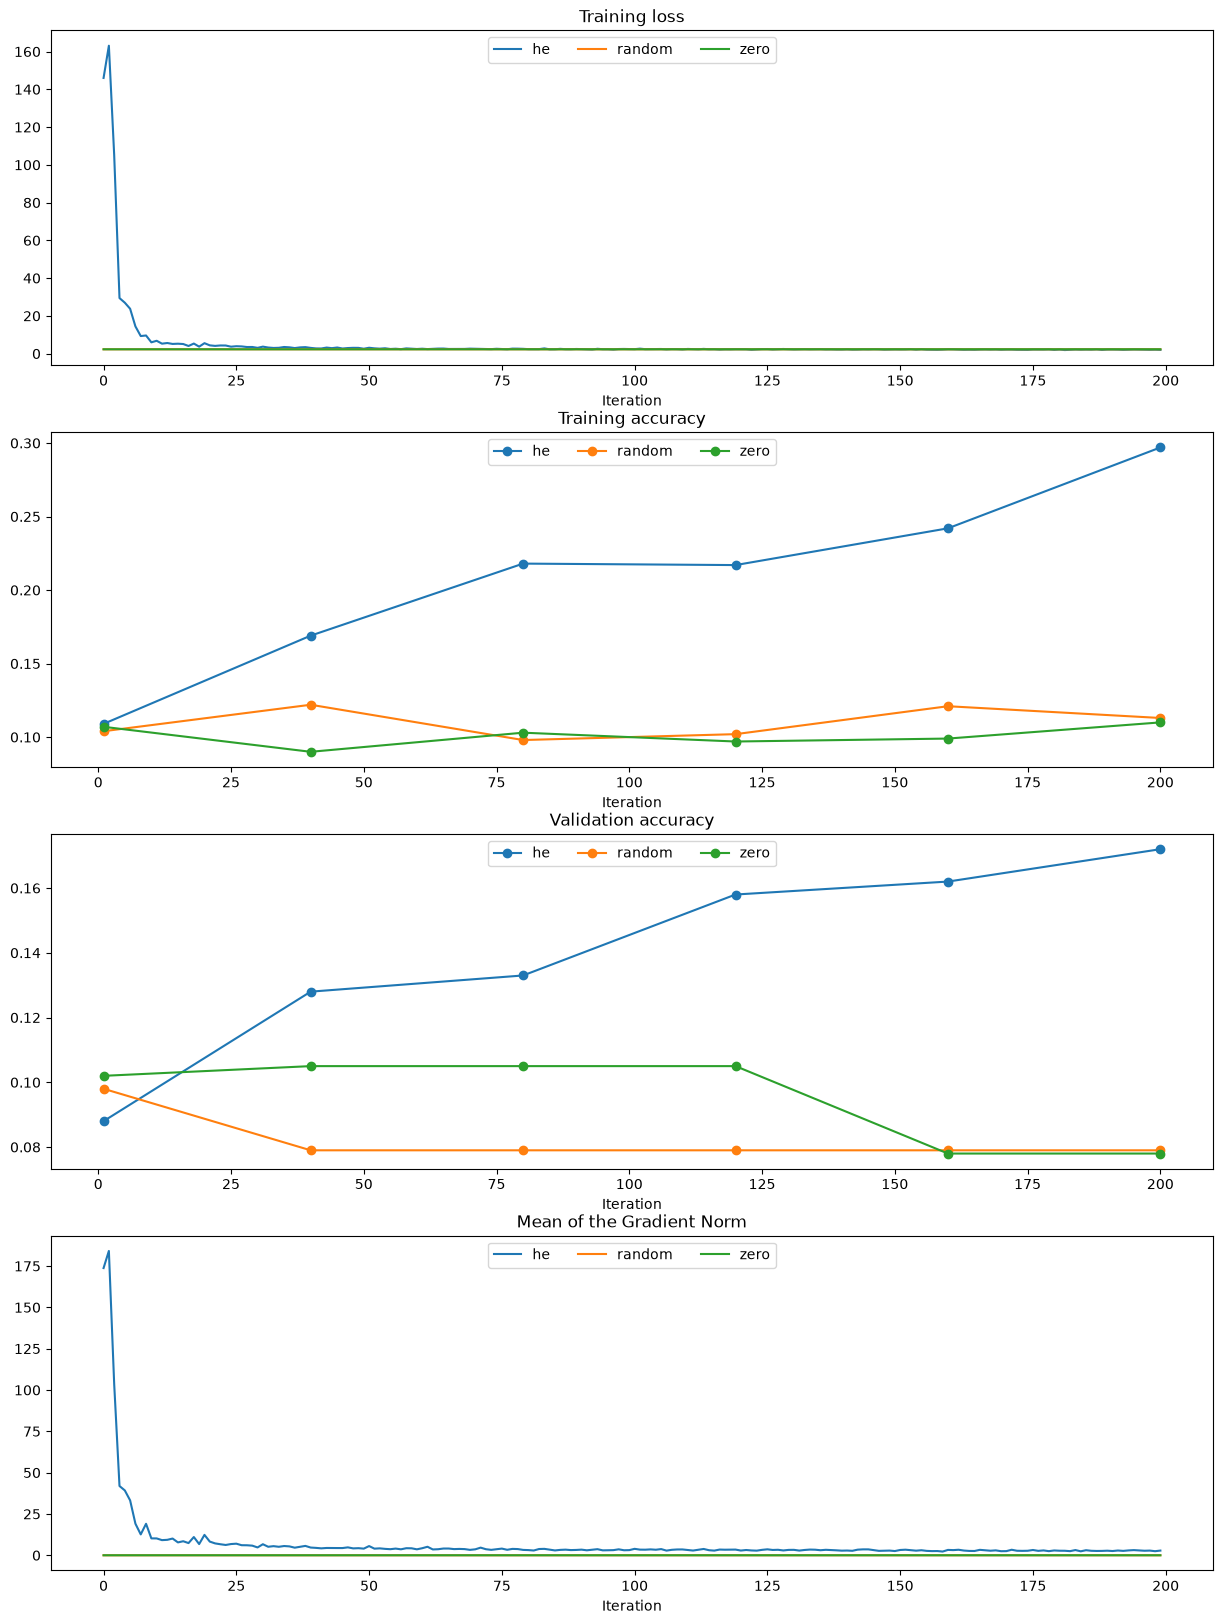

In [15]:
learning_rates = {'sgd': 1e-3}
update_rule = 'sgd'
solvers = dict()

num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

for initialization in ['he', 'random', 'zero']:
    np.random.seed(7)
    print('running with', initialization, 'and', update_rule)

    model = FullyConnectedNet([50]*10, initialization=initialization)
    weight_stds = [float(model.params["W" + str(i)].std()) for i in range(1, 12)]
    print("initialization scheme:", initialization)
    if initialization == "he":
        # It is fine if the rel_error is less than 0.03 due to randomness
        print("Layer 1, rel_error", rel_error(0.02551551815399, weight_stds[0]))
        print("Layer 2, rel_error", rel_error(0.2, weight_stds[1]))
    elif initialization == "random":
        # It is fine if the rel_error is less than 0.03 due to randomness
        print("Layer 1, rel_error", rel_error(0.01, weight_stds[0]))
        print("Layer 2, rel_error", rel_error(0.01, weight_stds[1]))
    with open("experiment_logs/w_stds_{}.json".format(initialization), "w", encoding="utf-8") as f:
        json.dump(weight_stds, f)

    solver = Solver(model, small_data,
                  num_epochs=5, batch_size=100,
                  update_rule=update_rule,
                  optim_config={
                    'learning_rate': learning_rates[update_rule]
                  },
                  verbose=True, log_acc_iteration=True, record_grad_norm=True)
    solvers[initialization] = solver
    solver.train()
    solver.record_histories_as_npz("experiment_logs/initialization_experiment_{}".format(initialization))
    print()

plt.subplot(4, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')


plt.subplot(4, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Iteration')

plt.subplot(4, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Iteration')

plt.subplot(4, 1, 4)
plt.title('Mean of the Gradient Norm')
plt.xlabel('Iteration')

for initialization, solver in solvers.items():
    plt.subplot(4, 1, 1)
    plt.plot(solver.loss_history, label=initialization)

    plt.subplot(4, 1, 2)
    plt.plot(solver.log_acc_iteration_history, solver.train_acc_history, '-o', label=initialization)

    plt.subplot(4, 1, 3)
    plt.plot(solver.log_acc_iteration_history, solver.val_acc_history, '-o', label=initialization)

    plt.subplot(4, 1, 4)
    plt.plot(solver.log_grad_norm_history, label=initialization)

for i in [1, 2, 3, 4]:
    plt.subplot(4, 1, i)
    plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 20)

plt.show()


### Question:

**In the plot titled "Mean of the Gradient Norm," compare zero, random Gaussian, and He initialization. Explain the differences and relate them to training behavior.** The plotted value is the average, over all weight and bias tensors, of the Euclidean norm of each flattened loss-gradient tensor; it is not the norm of the average gradient.

*Hint: Consider how signals and gradients pass through many ReLU layers, and whether the output bias can change even if hidden features do not.* Write your answer on the written assignment.


**Solution.** In this experiment the fixed random initialization uses standard deviation $0.01$ in a network with ten hidden layers of width 50. Each layer multiplies the signal by roughly $0.01\sqrt{50/2} \approx 0.05$, so activations and weight gradients become tiny across this depth. Its mean gradient norm stays around $4 \times 10^{-3}$ for the whole run, and the network stays at chance accuracy (about 10%), slowing learning to a halt. He initialization scales the weights with the layer width ($\sqrt{2/\text{fan-in}} \approx 0.2$ here) to preserve signal and gradient magnitudes through the ReLU layers. Its mean gradient norm starts large (about 170) and falls to about 3 as the loss decreases, and it is the only one of the three that learns (29.7% training accuracy after 5 epochs).

With all weights and biases initialized to zero, this deep ReLU network has zero weight gradients and cannot learn differentiated hidden features. Its final output bias can still receive a nonzero gradient from a minibatch with unequal class frequencies, and because the plotted average includes biases, the zero-initialization curve is small (around $4 \times 10^{-3}$) but not exactly zero. Only that bias moves, so the predictions change by class frequency alone and accuracy stays at chance.

# Train the supplied deeper model

Run the supplied ten-hidden-layer network with width 200, He initialization, and Adam. The reference settings have been verified to exceed 45% validation accuracy on the prescribed split; exact results can vary with the numerical environment. Inspect the validation trajectory and the checkpoint selected by the solver.

Optional exploration may change the learning rate, epoch budget, batch size, or learning-rate decay. Choose configurations using validation data, and keep test data out of that choice.


In [16]:
# Supplied reference configuration.
width = 200
n_layers = 10
lr = 5e-3
num_epochs = 10
batch_size = 100
lr_decay = 0.9
update_rule = 'adam'
################################################################################
################################################################################

np.random.seed(2026)  # please don't change this for reproducibility
model = FullyConnectedNet([width] * n_layers, 
                          initialization='he'
                          )
solver = Solver(model, 
                data,
                num_epochs=num_epochs, 
                batch_size=batch_size,
                update_rule=update_rule,
                optim_config={
                  'learning_rate': lr
                },
                lr_decay=lr_decay,
                verbose=True)
solver.train()
best_model = model
best_solver = solver


(Iteration 1 / 4900) loss: 149.301392
(Epoch 0 / 10) train acc: 0.112000; val_acc: 0.080000
(Iteration 11 / 4900) loss: 12.684223


(Iteration 21 / 4900) loss: 6.538347
(Iteration 31 / 4900) loss: 3.197673


(Iteration 41 / 4900) loss: 2.529083
(Iteration 51 / 4900) loss: 2.391104


(Iteration 61 / 4900) loss: 2.176154
(Iteration 71 / 4900) loss: 2.130801


(Iteration 81 / 4900) loss: 2.254859
(Iteration 91 / 4900) loss: 2.112288


...

(Iteration 4821 / 4900) loss: 1.400921
(Iteration 4831 / 4900) loss: 1.512175


(Iteration 4841 / 4900) loss: 1.545211
(Iteration 4851 / 4900) loss: 1.428927


(Iteration 4861 / 4900) loss: 1.288632
(Iteration 4871 / 4900) loss: 1.307996


(Iteration 4881 / 4900) loss: 1.292858
(Iteration 4891 / 4900) loss: 1.331351


(Epoch 10 / 10) train acc: 0.516000; val_acc: 0.476000


# Evaluate the selected model

After the final training run selects its best validation checkpoint, evaluate the prescribed test subset once. The cell records the measurements in `experiment_logs/results.json` for inspection.


In [17]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
val_acc = (y_val_pred == data['y_val']).mean()
test_acc = (y_test_pred == data['y_test']).mean()
print ('Validation set accuracy: ', val_acc)
print ('Test set accuracy: ', test_acc)
best_solver.record_histories_as_npz('experiment_logs/best_fc_model.npz')
import json
with open("experiment_logs/results.json", "w", encoding="utf-8") as f:
    json.dump(dict(
        val_acc = val_acc,
        test_acc = test_acc,
        lr = lr,
        num_epochs = num_epochs,
        batch_size = batch_size,
        lr_decay = lr_decay,
        update_rule = update_rule
    ), f)


Validation set accuracy:  0.476
Test set accuracy:  0.487


**Solution.** In this run the solver selected the checkpoint with the best validation accuracy, 47.6% (after epoch 10), and the single evaluation on the test subset gave 48.7%, above the 45% target. Exact numbers vary slightly with the numerical environment.